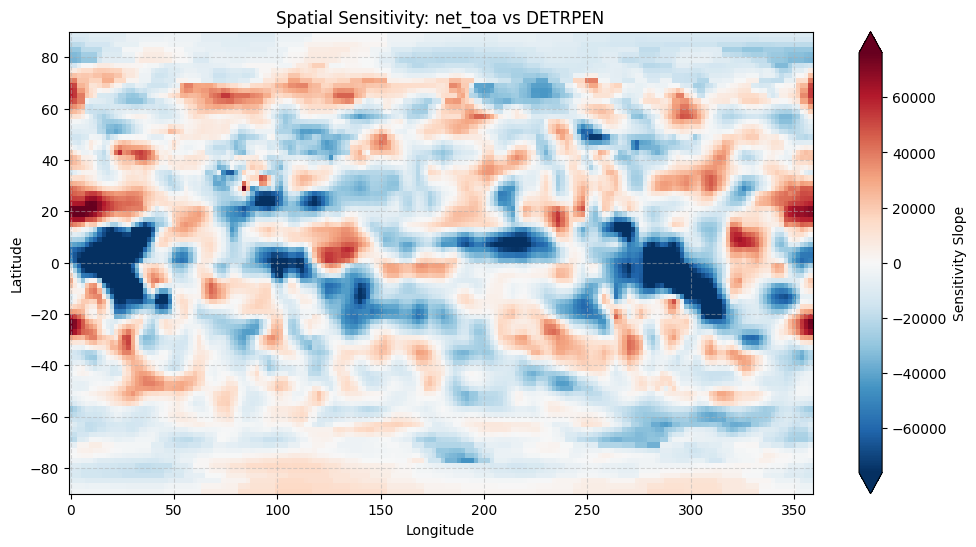

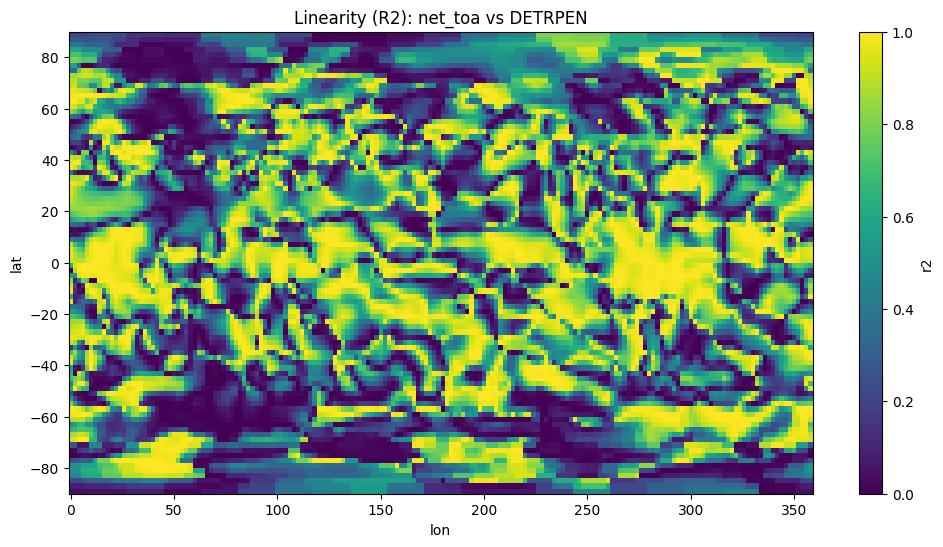

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np


ds = xr.open_dataset('../../ectuner/sensitivities/2D/sensitivity_TL63_415_1991-2000_2D.nc')

var_to_plot = 'net_toa'
param_to_plot = 'DETRPEN'

data_slice = ds.sel(variable=var_to_plot, parameter=param_to_plot)


plt.figure(figsize=(12, 6))

# Plot della pendenza (slope)
plot = data_slice.slope.plot(
    cmap='RdBu_r', 
    robust=True, 
    cbar_kwargs={'label': 'Sensitivity Slope'}
)

plt.title(f"Spatial Sensitivity: {var_to_plot} vs {param_to_plot}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# linearità (R2)
plt.figure(figsize=(12, 6))
data_slice.r2.plot(cmap='viridis', vmin=0, vmax=1)
plt.title(f"Linearity (R2): {var_to_plot} vs {param_to_plot}")
plt.show()

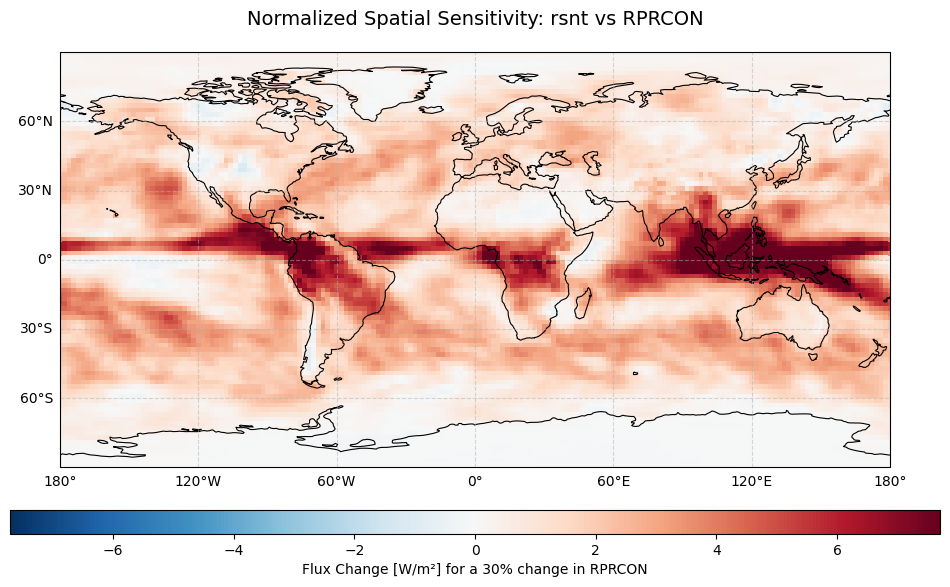

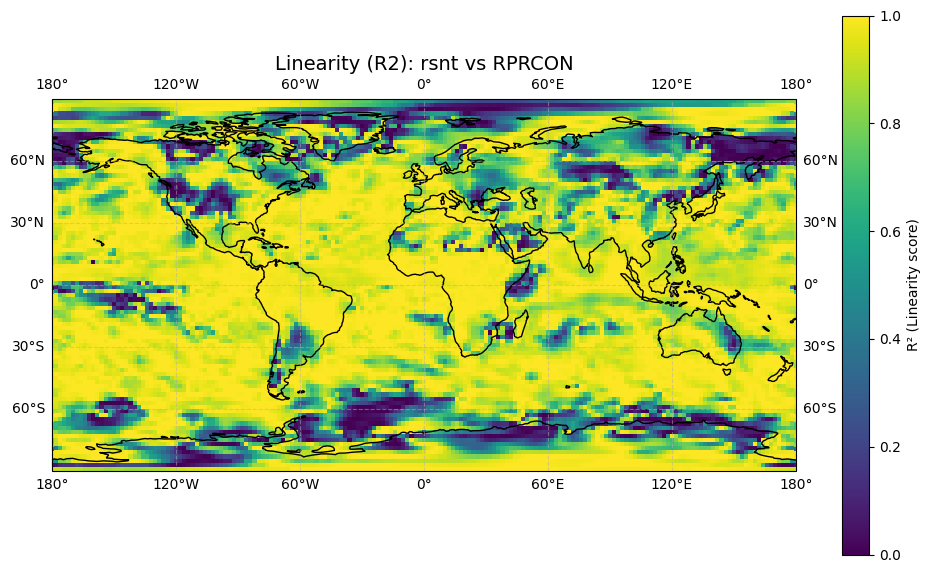

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature


ds = xr.open_dataset('../../ectuner/sensitivities/2D/sensitivity_TL255_415_1991-2000_v2_2D.nc')

var_to_plot = 'rsnt'
param_to_plot = 'RPRCON'

# reference value 
ref_val = 0.14E-02  # RPRCON
data_slice = ds.sel(variable=var_to_plot, parameter=param_to_plot)

# --- PLOT 1: SENSITIVITY SLOPE ---
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Normalized slope
sensitivity_scaled = data_slice.slope * ref_val * 0.3

vmax_limit = np.nanpercentile(np.abs(sensitivity_scaled), 98)
plot = sensitivity_scaled.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r', 
    robust=True,
    vmin=-vmax_limit, vmax=vmax_limit,
    add_colorbar=False
)


ax.coastlines(resolution='110m', color='black', linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='#f9f9f9', zorder=0)
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(plot, ax=ax, orientation='horizontal', pad=0.08, aspect=40, 
             label=f'Flux Change [W/m²] for a 30% change in {param_to_plot}')

plt.title(f"Normalized Spatial Sensitivity: {var_to_plot} vs {param_to_plot}", fontsize=14, pad=20)
plt.show()

# --- PLOT 2: LINEARITY (R2) ---
fig = plt.figure(figsize=(12, 7))
ax_r2 = plt.axes(projection=ccrs.PlateCarree())

data_slice.r2.plot(
    ax=ax_r2,
    transform=ccrs.PlateCarree(),
    cmap='viridis', 
    vmin=0, vmax=1,
    cbar_kwargs={'label': 'R² (Linearity score)'}
)

ax_r2.coastlines()
ax_r2.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
plt.title(f"Linearity (R2): {var_to_plot} vs {param_to_plot}", fontsize=14)
plt.show()

In [5]:
print(ds.info())
print(ds.slope.values[ds.variable == 'net_toa'][:, ds.parameter == 'DETRPEN'])

xarray.Dataset {
dimensions:
	variable = 11 ;
	parameter = 16 ;
	lat = 90 ;
	lon = 180 ;

variables:
	float64 slope(variable, parameter, lat, lon) ;
	float64 r2(variable, parameter, lat, lon) ;
	<U7 variable(variable) ;
	<U17 parameter(parameter) ;
	float64 lat(lat) ;
	float64 lon(lon) ;

// global attributes:
}None
[[[[ -2685.546875    -2685.546875    -2685.546875   ...  -2685.546875
     -2685.546875    -2685.546875  ]
   [ -4417.52941292  -4417.52941292  -4417.52941292 ...  -4231.02665466
     -4417.52941292  -4417.52941292]
   [ -8442.85753038  -8442.85753038  -8442.85753038 ...  -7822.88276661
     -8442.85753038  -8442.85753038]
   ...
   [-19770.47390408 -19770.47390408 -19770.47390408 ... -19707.74172652
    -19770.47390408 -19770.47390408]
   [-13711.38188677 -13711.38188677 -13711.38188677 ... -13692.51910855
    -13711.38188677 -13711.38188677]
   [-11104.32942708 -11104.32942708 -11104.32942708 ... -11104.32942708
    -11104.32942708 -11104.32942708]]]]


In [5]:
# Calcoliamo i pesi basati sul coseno della latitudine
weights = np.cos(np.deg2rad(ds.lat))

# Estraiamo la mappa dello slope per net_toa vs DETRPEN
slope_map = ds.slope.sel(variable='net_toa', parameter='ENTRORG')

# Calcoliamo la media globale pesata
global_mean_slope = slope_map.weighted(weights).mean().values

print(f"Global Mean Slope (dal 2D): {global_mean_slope:.4f}")
print(f"Global Mean Slope (dallo YAML 1D): -4642.1764)")
print(f"Differenza: {global_mean_slope - (-4642.1764):.4f}")

Global Mean Slope (dal 2D): -4640.6167
Global Mean Slope (dallo YAML 1D): -4642.1764)
Differenza: 1.5597


In [6]:
# Calcoliamo i pesi basati sul coseno della latitudine
weights = np.cos(np.deg2rad(ds.lat))

# Estraiamo la mappa dello slope per net_toa vs DETRPEN
slope_map = ds.slope.sel(variable='net_toa', parameter='RPRCON')

# Calcoliamo la media globale pesata
global_mean_slope = slope_map.weighted(weights).mean().values

print(f"Global Mean Slope (dal 2D): {global_mean_slope:.4f}")
print(f"Global Mean Slope (dallo YAML 1D): 254.549")
print(f"Differenza: {global_mean_slope - (254.549):.4f}")

Global Mean Slope (dal 2D): 254.6150
Global Mean Slope (dallo YAML 1D): 254.549
Differenza: 0.0660


In [8]:
# Calcoliamo i pesi basati sul coseno della latitudine
weights = np.cos(np.deg2rad(ds.lat))

# Estraiamo la mappa dello slope per net_toa vs DETRPEN
slope_map = ds.slope.sel(variable='net_toa', parameter='RVICE')

# Calcoliamo la media globale pesata
global_mean_slope = slope_map.weighted(weights).mean().values

print(f"Global Mean Slope (dal 2D): {global_mean_slope:.4f}")
print(f"Global Mean Slope (dallo YAML 1D): -12.4751")
print(f"Differenza: {global_mean_slope - (-12.4751):.4f}")

Global Mean Slope (dal 2D): -12.4745
Global Mean Slope (dallo YAML 1D): -12.4751
Differenza: 0.0006


In [7]:
# Media pesata solo nei Tropici
tropical_slope = slope_map.sel(lat=slice(-30, 30)).weighted(weights.sel(lat=slice(-30, 30))).mean().values

print(f"Tropical Mean Slope (2D): {tropical_slope:.4f}")
print(f"Tropical Mean Slope (1D YAML): -13844.3841") # Preso dal tuo pezzo di log 1D

Tropical Mean Slope (2D): -14139.4016
Tropical Mean Slope (1D YAML): -13844.3841
